# Variance Gamma Option Pricing via Carr-Madan FFT

Calibration of the Variance Gamma (VG) model to SPX implied volatility surface 
using the Carr-Madan FFT pricing framework. Market data sourced from Yahoo Finance.

## 1. FFT Pricing Engine
Implementation of the Carr-Madan (1999) algorithm. The VG characteristic function 
is used to price calls across a log-strike grid via FFT.

Using the formula: 
$$
C(k_u) = \frac{\exp(-\alpha k_u)}{\pi}FFT(x(j)), \quad x(j)=e^{ib \nu_j}\psi(\nu_j)\frac{\eta}{3}[3+(-1)^j-\delta_{j-1}]
$$
The Simpson's rule weights $\frac{\eta}{3}[3+(-1)^j - \delta_{j-1}]$ are applied to improve the accuracy of the numerical integration over the trapezoidal rule.

Using the definition of the FFT:
$$
w(k)=\sum_{j=1}^N e^{-i\frac{2\pi}{N}(j-1)(k-1)}x(j), \quad \text{for } k=1,2,...,N
$$

And knowing:
$$
\psi_T(\nu)=\frac{e^{-rT}\phi_T(\nu-(\alpha+1)i)}{\alpha^2+\alpha-\nu^2+i(2\alpha+1)\nu}
$$

where $\phi_T(u)$ is the characteristic function and is supposed to be known analatically. For the Black-Scholes-Merton model we have 
$$
\phi_{BSM}(u)=\exp(iu[\log S_0 +(r-\frac{1}{2}\sigma^2)T]-\frac{1}{2}\sigma^2u^2T)
$$

In the VG model we have:
$$
\phi_{VG}(u)=\exp(iu[\log S_0 + (r+w)T])[1-i\theta\nu u + \frac{1}{2}\sigma^2u^2\nu]^{-\frac{T}{\nu}}
$$
where we set $w=\frac{1}{\nu}\log(1-\theta\nu-\frac{1}{2}\sigma^2\nu)$ so that the mean return of the stock is equal to the risk free-rate $r$.

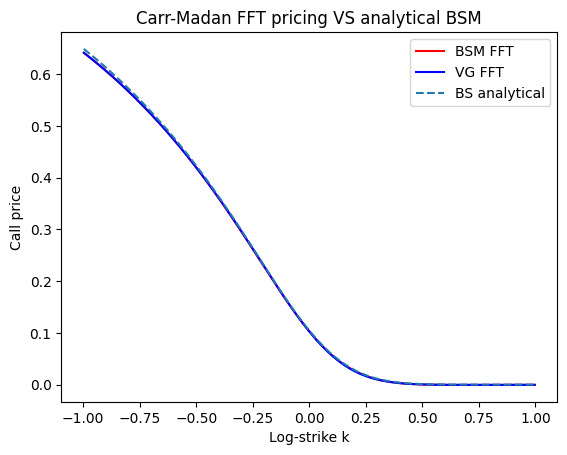

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

N = 8192
eta = 0.05
alpha = 1.5

def C_ITM(r, T, N, S_0, theta, sigma, v, eta, alpha, phi):
    lambda_1 = (2*np.pi)/(N*eta)
    b = 0.5 * N * lambda_1
    k = np.array([-b + lambda_1*(u - 1) for u in range(1,N+1)])
    nu = np.array([eta*(j-1) for j in range(1, N+1)])
    weights = (3 + (-1)**np.arange(N)).astype(float)
    weights[0] = 1
    weights[-1] = 1

    psi = ((np.exp(-r*T))*phi(r, T, S_0, theta, sigma, v, nu - (alpha + 1)*1j))/(alpha**2 + alpha - nu**2 + 1j*(2*alpha + 1)*nu)
    x = np.exp(1j*b*nu)*psi*(eta/3) * weights
    return k, (np.exp(-alpha * k)/np.pi) * np.real(np.fft.fft(x))

#Test VG

S_0 = 1
theta = -0.1
sigma = 0.2
v = 0.1

def phi(r, T, S_0, theta, sigma, v, u):
    omega = (1/v)*np.log(1 - theta * v - 0.5 * sigma**2 * v)
    return np.exp(1j*u*(np.log(S_0) + (r+omega)*T))*(1 - 1j * theta*v*u + 0.5 * sigma**2 * u**2 * v)**(-T/v)

k, C = C_ITM(0.05, 1, N, S_0, theta, sigma, v, eta, alpha, phi)

mask = (k >= -1) & (k <= 1)

#Test BSM

def phi_BSM(r, T, S_0, theta, sigma, v, u):
    return np.exp(1j*u*(np.log(S_0) + (r - 0.5*sigma**2)*T) - 0.5*sigma**2*u**2*T)

k_BSM, C_BSM = C_ITM(0.05, 1, N, S_0, theta, sigma, v, eta, alpha, phi_BSM)

def BS_call(S0, K, r, T, sigma):
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

BS_prices = BS_call(S_0, np.exp(k[mask]), 0.05, 1, sigma)
plt.plot(k_BSM[mask], C_BSM[mask], label='BSM FFT', color = 'red')
plt.plot(k[mask], C[mask], label='VG FFT', color = 'blue')
plt.plot(k_BSM[mask], BS_prices, label='BS analytical', linestyle='--')
plt.xlabel('Log-strike k')
plt.ylabel('Call price')
plt.title('Carr-Madan FFT pricing VS analytical BSM')
plt.legend()
plt.show()



## 2. Market Data
SPX option chain for 3 maturities (24d, 53d, 81d). Risk-free rate from 3-month T-bill. 
IV extracted by inverting BSM numerically (Brent method).

In [2]:
import yfinance as yf
from datetime import datetime

ticker = yf.Ticker("^SPX")
df = ticker.option_chain('2026-06-25').calls
S = yf.Ticker("^SPX").history(period="1d")["Close"].iloc[-1]
tbill = yf.Ticker("^IRX")
r = tbill.history(period="1d")["Close"].iloc[-1] / 100
print(r)

df_filtered = df[(df['bid']>0) & (df['strike']/S > 0.9) & (df['strike']/S < 1.10) ]
df_filtered['mid_price'] = (df_filtered['ask'] + df_filtered['bid'])/2
df_filtered.head()

0.03588000059127808


C:\Users\victo\AppData\Local\Temp\ipykernel_56344\2248050544.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['mid_price'] = (df_filtered['ask'] + df_filtered['bid'])/2


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,mid_price
3,SPXW260625C06850000,2026-05-12 15:24:30+00:00,6850.0,562.91,738.4,762.4,0.00,0.00000,NaN,5,0.311328,True,REGULAR,USD,750.4
4,SPXW260625C06875000,2026-05-12 15:24:30+00:00,6875.0,540.65,713.9,737.9,0.00,0.00000,NaN,5,0.304473,True,REGULAR,USD,725.9
5,SPXW260625C06900000,2026-05-27 13:30:04+00:00,6900.0,656.77,689.5,713.5,0.00,0.00000,2.0,3,0.297805,True,REGULAR,USD,701.5
6,SPXW260625C07050000,2026-05-29 15:04:49+00:00,7050.0,558.13,544.5,568.5,154.13,38.15099,1.0,1,0.259166,True,REGULAR,USD,556.5
7,SPXW260625C07100000,2026-05-26 16:18:22+00:00,7100.0,454.56,496.8,520.8,0.00,0.00000,3.0,7,0.246658,True,REGULAR,USD,508.8


## Market Data & IV Extraction

SPX option chains are fetched for 3 maturities via `yfinance`. We filter to liquid 
strikes only (`bid > 0`, `|log(K/S)| < 0.05`) and compute mid-prices.

Implied volatility is extracted by numerically inverting the BSM formula for each 
strike using Brent's method:

$$\sigma^*_i = \text{arg} \{ C_{BSM}(S, K_i, r, T, \sigma) = C^{mid}_i \}$$

Prices are normalized by spot $S$ throughout (i.e. $S_0 = 1$) to avoid numerical 
scaling issues in the FFT pricing step.

30d → 2026-07-01 (T=0.0822)
60d → 2026-07-31 (T=0.1644)
90d → 2026-08-31 (T=0.2493)


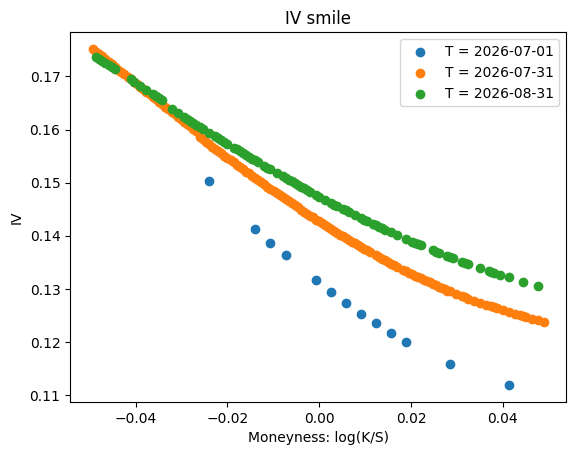

In [3]:
from datetime import datetime, timedelta

today = datetime.today()
target_30 = today + timedelta(days=30)
target_60 = today + timedelta(days=60)
target_90 = today + timedelta(days=90)

expirations = ticker.options
expirations_dt = [datetime.strptime(e, '%Y-%m-%d') for e in expirations]

# Finding the nearest maturity for each target date
def nearest_expiry(target, expirations_dt, expirations):
    idx = min(range(len(expirations_dt)), key=lambda i: abs((expirations_dt[i] - target).days))
    return expirations[idx], expirations_dt[idx]

exp_30, dt_30 = nearest_expiry(target_30, expirations_dt, expirations)
exp_60, dt_60 = nearest_expiry(target_60, expirations_dt, expirations)
exp_90, dt_90 = nearest_expiry(target_90, expirations_dt, expirations)

T_30d = (dt_30 - today).days / 365
T_60d = (dt_60 - today).days / 365
T_90d = (dt_90 - today).days / 365

print(f"30d → {exp_30} (T={T_30d:.4f})")
print(f"60d → {exp_60} (T={T_60d:.4f})")
print(f"90d → {exp_90} (T={T_90d:.4f})")


from scipy.optimize import brentq

def get_iv(row, T_i):
    K = row["strike"] / S
    mid = row["mid_price"] / S
    try:
        iv = brentq(lambda sigma: BS_call(1, K, r, T_i, sigma) - mid, 1e-6, 5.0)
        return iv
    except:
        return np.nan


df_30d = ticker.option_chain(exp_30).calls
df_60d = ticker.option_chain(exp_60).calls
df_90d = ticker.option_chain(exp_90).calls
S = yf.Ticker("^SPX").history(period="1d")["Close"].iloc[-1]

df_filtered_30d = df_30d[(df_30d['bid']>0) & (df_30d['strike']/S > 0.9) & (df_30d['strike']/S < 1.10) & (np.log(df_30d['strike']/S) > -0.05) & (np.log(df_30d['strike']/S) < 0.05)].copy()
df_filtered_60d = df_60d[(df_60d['bid']>0) & (df_60d['strike']/S > 0.9) & (df_60d['strike']/S < 1.10) & (np.log(df_60d['strike']/S) > -0.05) & (np.log(df_60d['strike']/S) < 0.05)].copy()
df_filtered_90d = df_90d[(df_90d['bid']>0) & (df_90d['strike']/S > 0.9) & (df_90d['strike']/S < 1.10) & (np.log(df_90d['strike']/S) > -0.05) & (np.log(df_90d['strike']/S) < 0.05)].copy()

df_filtered_30d['mid_price'] = (df_filtered_30d['ask'] + df_filtered_30d['bid'])/2
df_filtered_60d['mid_price'] = (df_filtered_60d['ask'] + df_filtered_60d['bid'])/2
df_filtered_90d['mid_price'] = (df_filtered_90d['ask'] + df_filtered_90d['bid'])/2

df_filtered_30d['iv_market'] = df_filtered_30d.apply(lambda row: get_iv(row, T_30d), axis=1)
df_filtered_60d['iv_market'] = df_filtered_60d.apply(lambda row: get_iv(row, T_60d), axis=1)
df_filtered_90d['iv_market'] = df_filtered_90d.apply(lambda row: get_iv(row, T_90d), axis=1)

df_filtered_30d['log(K/S)'] = np.log(df_filtered_30d['strike']/S)
df_filtered_60d['log(K/S)'] = np.log(df_filtered_60d['strike']/S)
df_filtered_90d['log(K/S)'] = np.log(df_filtered_90d['strike']/S)

plt.scatter(df_filtered_30d['log(K/S)'], df_filtered_30d['iv_market'], label = f'T = {exp_30}')
plt.scatter(df_filtered_60d['log(K/S)'], df_filtered_60d['iv_market'], label = f'T = {exp_60}')
plt.scatter(df_filtered_90d['log(K/S)'], df_filtered_90d['iv_market'], label = f'T = {exp_90}')
plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('IV')
plt.title('IV smile')
plt.show()


## SPX Implied Volatility Surface

Market IV extracted from SPX option mid-prices across 3 maturities (24d, 53d, 81d).

Two stylized facts are immediately visible:

**Negative skew** — IV decreases monotonically with strike for all maturities. 
This reflects the persistent demand for OTM puts as portfolio hedges, a structural 
feature of equity index options absent in single stocks or crypto.

**Normal term structure** — IV increases with maturity at all strikes. 
Short-dated options are cheaper in IV terms, consistent with a low-volatility 
regime (VIX ~15 at time of data collection).

Note the absence of a symmetric smile: the VG model, which can generate both 
skew and kurtosis, will be primarily constrained by the skew parameter θ here.

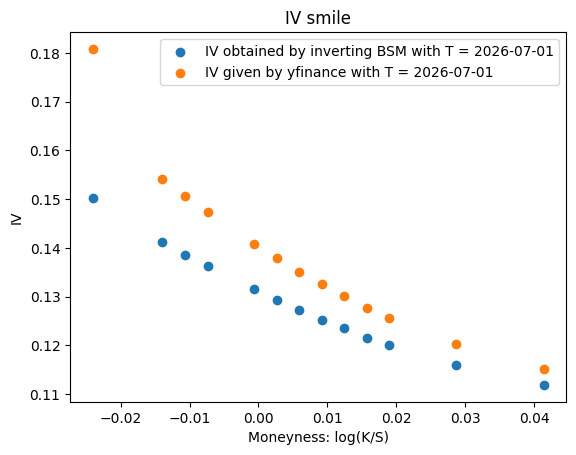

In [4]:
plt.scatter(df_filtered_30d['log(K/S)'], df_filtered_30d['iv_market'], label = f'IV obtained by inverting BSM with T = {exp_30}')
plt.scatter(df_filtered_30d['log(K/S)'], df_filtered_30d['impliedVolatility'], label = f'IV given by yfinance with T = {exp_30}')
plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('IV')
plt.title('IV smile')
plt.show()

## Sanity Check: BSM IV vs yfinance implied volatility

We compare our BSM-inverted IV against the implied volatility provided directly 
by yfinance. The two series diverge significantly for OTM puts (deep negative moneyness), 
which suggests that yfinance uses a different convention — likely calendar days vs 
trading days for T, or a different risk-free rate. 

For ATM and OTM calls (log(K/S) > -0.01), both series converge, giving us confidence 
that our IV extraction is correct in the liquid part of the smile. We use our 
BSM-inverted IV throughout, as it gives full control over the inputs (r, T, S).

## 3. VG Calibration
Per-maturity calibration minimizing IV RMSE. L-BFGS-B optimizer with multiple 
starting points to avoid local minima.

0.0821917808219178 [-0.20657969  0.14775701  0.08723346] 0.0009899915157140866
0.1643835616438356 [-0.13470482  0.16200352  0.24857413] 0.001517918070063007
0.2493150684931507 [-0.09646073  0.16972589  0.40511618] 0.0010076326183206398


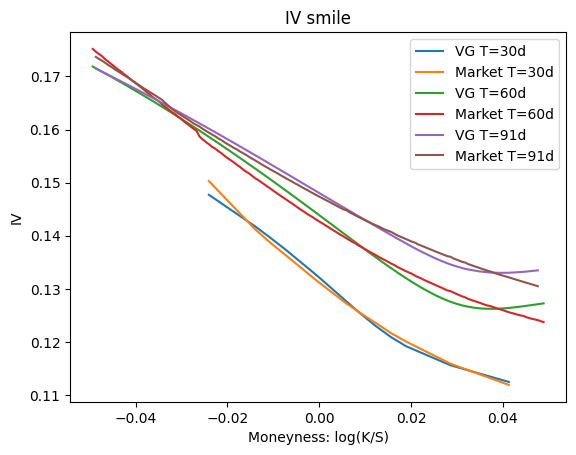

In [5]:
from scipy.optimize import minimize, brentq
from scipy.interpolate import CubicSpline

T = [T_30d, T_60d, T_90d]
df_filtered_tot = [df_filtered_30d, df_filtered_60d, df_filtered_90d]

def make_ivrmse(T_i, df_i):
    def ivrmse(params):
        theta, sigma, v = params
        iv_VG = []
        k, C = C_ITM(0.05, T_i, N, 1, theta, sigma, v, eta, alpha, phi)
        mask = (k > -0.5) & (k < 0.5)
        cs = CubicSpline(k[mask], C[mask])

        for i in df_i['strike']:
            k_target = np.log(i / S)
            price_VG = cs(k_target)
            try:
                iv = brentq(lambda sv: BS_call(1, i/S, 0.05, T_i, sv) - price_VG, 1e-6, 5.0)
            except:
                iv = np.nan
            iv_VG.append(iv)

        diff = np.array(iv_VG) - np.array(df_i['iv_market'])
        return np.sqrt(np.nanmean(diff**2))
    return ivrmse

bounds = [(-1, 0), (0.01, 1), (0.01, 2)]
x0_candidates = [
    [-0.1, 0.2, 0.1],
    [-0.3, 0.15, 0.5],
    [-0.05, 0.25, 0.3],
]

x=[]
for T_i, df_i in zip([T_30d, T_60d, T_90d], [df_filtered_30d, df_filtered_60d, df_filtered_90d]):
    results = [minimize(make_ivrmse(T_i, df_i), x0, method='L-BFGS-B', bounds=bounds) for x0 in x0_candidates]
    result = min(results, key=lambda r: r.fun)
    x.append(result.x)
    print(T_i, result.x, result.fun)

for j in range(len(T)):
    theta, sigma, v = x[j]
    df = df_filtered_tot[j]
    T_i = T[j]
    iv_VG = []
    k, C = C_ITM(0.05, T_i, N, 1, theta, sigma, v, eta, alpha, phi)
    mask = (k > -0.5) & (k < 0.5)
    cs = CubicSpline(k[mask], C[mask])

    for i in df['strike']:
        k_target = np.log(i / S)
        price_VG = cs(k_target)
        try:
            iv = brentq(lambda sv: BS_call(1, i/S, 0.05, T_i, sv) - price_VG, 1e-6, 5.0)
        except:
            iv = np.nan
        iv_VG.append(iv)
    #iv_VG_tot[j] = iv_VG
    plt.plot(df['log(K/S)'], iv_VG, label=f'VG T={round(T_i*365)}d')
    plt.plot(df['log(K/S)'], df['iv_market'], label=f'Market T={round(T_i*365)}d')

plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('IV')
plt.title('IV smile')
plt.show()

## 4. Results & Discussion

Calibrated parameters and RMSE per maturity:

| Maturity | $\theta$ | $\sigma$ | $\nu$ | RMSE |
|----------|-------|-------|-------|------|
| 30d | -0.207 | 0.148 | 0.087 | 0.00099 |
| 60d | -0.135 | 0.162 | 0.249 | 0.00152 |
| 90d | -0.096 | 0.170 | 0.405 | 0.00101 |

The VG model achieves good fit across all maturities (RMSE < 0.002), with the 
best performance on the 30d slice. Residual errors are concentrated at the 
extremes of the moneyness range, where liquidity is lower and the VG tails 
are insufficiently heavy to match the steep SPX skew.

Three structural observations from the calibrated parameters:
- **$\theta$ becomes less negative with T**: the skew attenuates at longer maturities, consistent with mean-reversion in equity vol
- **$\nu$ increases strongly with T** (0.087 → 0.405): more stochastic time-change variance at longer horizons, the process drifts away from Brownian motion
- **$\sigma$ is stable across maturities** (~0.15-0.17): the diffusion component is largely maturity-independent

The IV difference plot confirms these findings. Extensions to richer models (Heston, SABR) 
would better capture the short-term skew via a dedicated mean-reversion parameter.

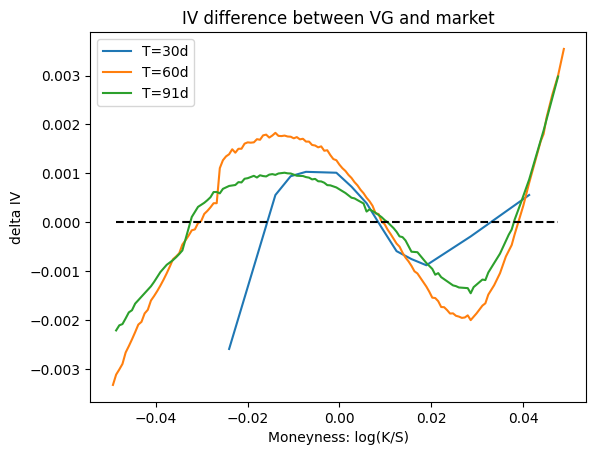

In [6]:
for j in range(len(T)):
    theta, sigma, v = x[j]
    df = df_filtered_tot[j]
    T_i = T[j]
    iv_VG = []
    k, C = C_ITM(0.05, T_i, N, 1, theta, sigma, v, eta, alpha, phi)
    mask = (k > -0.5) & (k < 0.5)
    cs = CubicSpline(k[mask], C[mask])

    for i in df['strike']:
        k_target = np.log(i / S)
        price_VG = cs(k_target)
        try:
            iv = brentq(lambda sv: BS_call(1, i/S, 0.05, T_i, sv) - price_VG, 1e-6, 5.0)
        except:
            iv = np.nan
        iv_VG.append(iv)
    #iv_VG_tot[j] = iv_VG
    plt.plot(df['log(K/S)'], iv_VG - df['iv_market'], label=f'T={round(T_i*365)}d')

plt.plot(df['log(K/S)'], np.zeros(len(df['log(K/S)'])), linestyle='--', color='black')
plt.legend()
plt.xlabel('Moneyness: log(K/S)')
plt.ylabel('delta IV')
plt.title('IV difference between VG and market')
plt.show()